In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
# Parámetros generales
image_height = 224
image_width = 224
batch_size = 32
epochs = 20
input_shape = (image_height, image_width, 3)
num_classes = None  # Se infiere del generador

data_dir = "Datos Finales Estado Balanceados"
metadata_file = "archivos_datos_balanceados_estado.csv"

df = pd.read_csv(metadata_file, sep=";")
df = df.rename(columns={'Nombre del archivo': 'image_id'})
df['Planta_Estado'] = df['Planta_Estado'].astype(str)

categoria = 'Planta_Estado'
image_id = 'image_id'

In [3]:
# Dividir en entrenamiento y validación
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['Planta_Estado'], random_state=42)
train_df.shape, test_df.shape

((50400, 7), (12601, 7))

In [4]:
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['Planta_Estado'], random_state=42)
train_df.shape, val_df.shape

((40320, 7), (10080, 7))

In [5]:
# Total de clases
print("Clases:", df['Planta_Estado'].nunique())
num_classes = df['Planta_Estado'].nunique()
class_names = df['Planta_Estado'].unique().tolist()
print(class_names)

Clases: 18
['Maíz_Enferma', 'Tomate_Saludable', 'Yuca_Enferma', 'Pepino Cohombro_Enferma', 'Tomate_Enferma', 'Manzana_Saludable', 'Fresa_Enferma', 'Maíz_Saludable', 'Papa_Enferma', 'Fresa_Saludable', 'Coliflor_Enferma', 'Pepino Cohombro_Saludable', 'Yuca_Saludable', 'Fríjol_Enferma', 'Papa_Saludable', 'Fríjol_Saludable', 'Coliflor_Saludable', 'Manzana_Enferma']


In [6]:
# Crear el generador de imágenes -- 
datagen = ImageDataGenerator(
    validation_split = 0.2,
    rescale=1./255,
    preprocessing_function = None,
    rotation_range = 45,
    zoom_range = 0.2,
    horizontal_flip = True,
    vertical_flip = True,
    fill_mode = 'nearest',
    shear_range = 0.1,
    height_shift_range = 0.1,
    width_shift_range = 0.1
)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=data_dir,
    x_col=image_id,
    y_col=categoria,
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',  # Importante para clasificación multiclase
    subset='training',
    seed=42,
    classes=class_names  # Asegurarse del orden de las clases
)

validation_generator = datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=data_dir,
    x_col=image_id,
    y_col=categoria,
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=42,
    classes=class_names
)

Found 32256 validated image filenames belonging to 18 classes.
Found 2015 validated image filenames belonging to 18 classes.


/opt/anaconda3/lib/python3.12/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="image_id". These filename(s) will be ignored.
  warnings.warn(


In [7]:
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,072,629 (15.54 MB)

 Trainable params: 23,058 (90.07 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)

In [9]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr]
)

/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 662s 653ms/step - accuracy: 0.0592 - loss: 2.9076 - val_accuracy: 0.0580 - val_loss: 2.8929 - learning_rate: 1.0000e-04
Epoch 2/20
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 668s 663ms/step - accuracy: 0.0589 - loss: 2.9065 - val_accuracy: 0.0565 - val_loss: 2.8917 - learning_rate: 1.0000e-04
Epoch 3/20
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 629s 624ms/step - accuracy: 0.0551 - loss: 2.9042 - val_accuracy: 0.0489 - val_loss: 2.8937 - learning_rate: 1.0000e-04
Epoch 4/20
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 485s 481ms/step - accuracy: 0.0561 - loss: 2.9056 - val_accuracy: 0.0559 - val_loss: 2.8886 - learning_rate: 1.0000e-04
Epoch 5/20
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 486s 482ms/step - accuracy: 0.0562 - loss: 2.9050 - val_accuracy: 0.0575 - val_loss: 2.8928 - learning_rate: 1.0000e-04
Epoch 6/20
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 489s 484ms/step - accuracy: 0.0554 - loss: 2.9013 - val_accuracy: 0.0474 - val_loss: 2.8911 - learning_rate: 1.0000e-04
Epoch 7/20
1008/1008 ━━━━━━━

In [10]:
print("\nEvaluando el modelo...")
evaluation_result = model.evaluate(validation_generator)
print(f"Pérdida en la validación: {evaluation_result[0]:.4f}")
print(f"Precisión en la validación: {evaluation_result[1]:.4f}")


Evaluando el modelo...
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 453ms/step - accuracy: 0.0960 - loss: 2.8836
Pérdida en la validación: 2.8836
Precisión en la validación: 0.0923


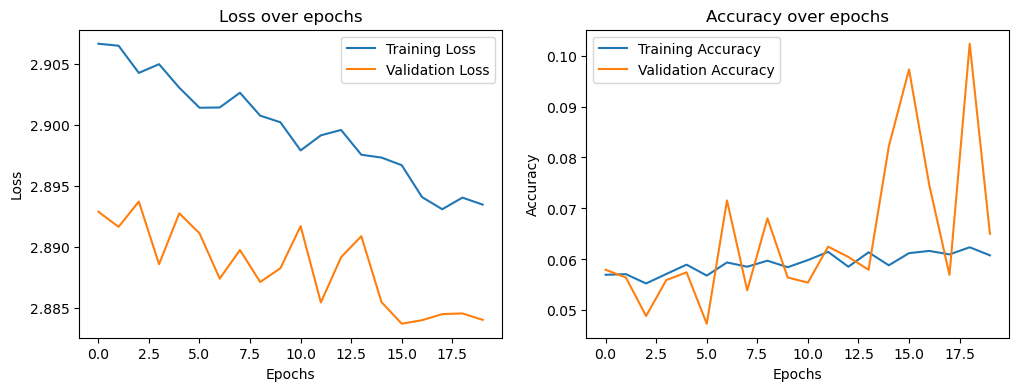

In [11]:
# Acceder a los datos de pérdida y precisión
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Graficar la pérdida del modelo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Graficar la precisión del modelo
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [12]:
epochs = list(range(1, 20))

loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']


data = {
    'Epoch': 20,
    'Trainning Loss': loss,
    'Validation Loss': val_loss,
    'Training Accuracy': accuracy,
    'Validation  Accuracy': val_accuracy
}
df = pd.DataFrame(data)

# Imprimir la tabla
print(df)

    Epoch  Trainning Loss  Validation Loss  Training Accuracy  \
0      20        2.906684         2.892892           0.056982   
1      20        2.906519         2.891653           0.057106   
2      20        2.904288         2.893730           0.055277   
3      20        2.905005         2.888590           0.057137   
4      20        2.903075         2.892761           0.058966   
5      20        2.901430         2.891125           0.056827   
6      20        2.901450         2.887402           0.059400   
7      20        2.902659         2.889747           0.058563   
8      20        2.900780         2.887125           0.059741   
9      20        2.900237         2.888257           0.058470   
10     20        2.897926         2.891711           0.059865   
11     20        2.899164         2.885446           0.061477   
12     20        2.899606         2.889157           0.058563   
13     20        2.897571         2.890884           0.061384   
14     20        2.897338

In [13]:
# Accuracy final en entrenamiento
val_loss = history.history['val_loss'][-1]

In [14]:
print('Perdida final en Train:', history.history['loss'][-1])
print("Pérdida final en Validation:", history.history['val_loss'][-1])


print("Accuracy final en Train:", history.history['accuracy'][-1])
print("Accuracy final en Validation:", history.history['val_accuracy'][-1])

Perdida final en Train: 2.893477439880371
Pérdida final en Validation: 2.8840203285217285
Accuracy final en Train: 0.0607948899269104
Accuracy final en Validation: 0.06502015888690948


In [15]:
test_df.Planta_Estado = test_df.Planta_Estado.astype('str')

datagen = ImageDataGenerator(
    validation_split = 0.2,
    preprocessing_function = None,
    rotation_range = 45,
    zoom_range = 0.2,
    horizontal_flip = True,
    vertical_flip = True,
    fill_mode = 'nearest',
    shear_range = 0.1,
    height_shift_range = 0.1,
    width_shift_range = 0.1)


test_generator =  datagen.flow_from_dataframe(test_df,
                         directory = data_dir,
                         x_col = image_id,
                         y_col = categoria,
                         target_size = (image_height,image_width),
                         batch_size = batch_size,
                         class_mode = "categorical")

Found 12601 validated image filenames belonging to 18 classes.


In [16]:
# -------------------------
# 1. Obtener predicciones completas para test
# -------------------------
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


394/394 ━━━━━━━━━━━━━━━━━━━━ 180s 454ms/step


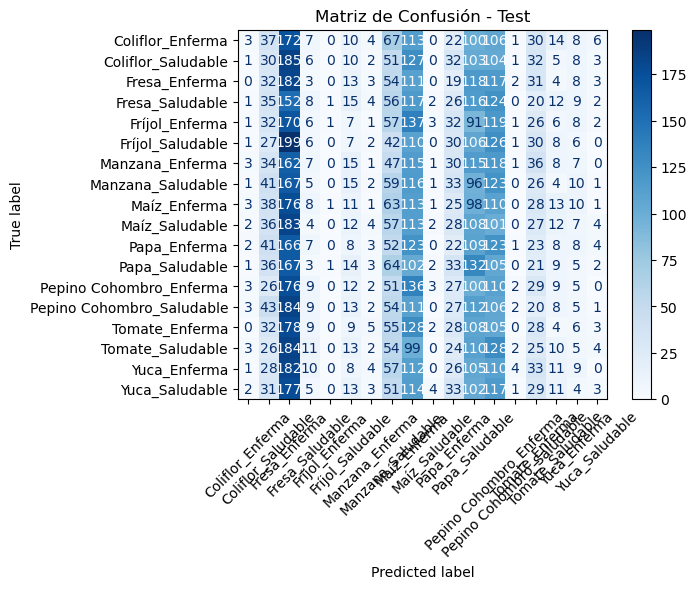

In [17]:
# -------------------------
# 2. Matriz de Confusión
# -------------------------
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - Test")
plt.show()

In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.0573


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


ValueError: num must be an integer with 1 <= num <= 12, not 13

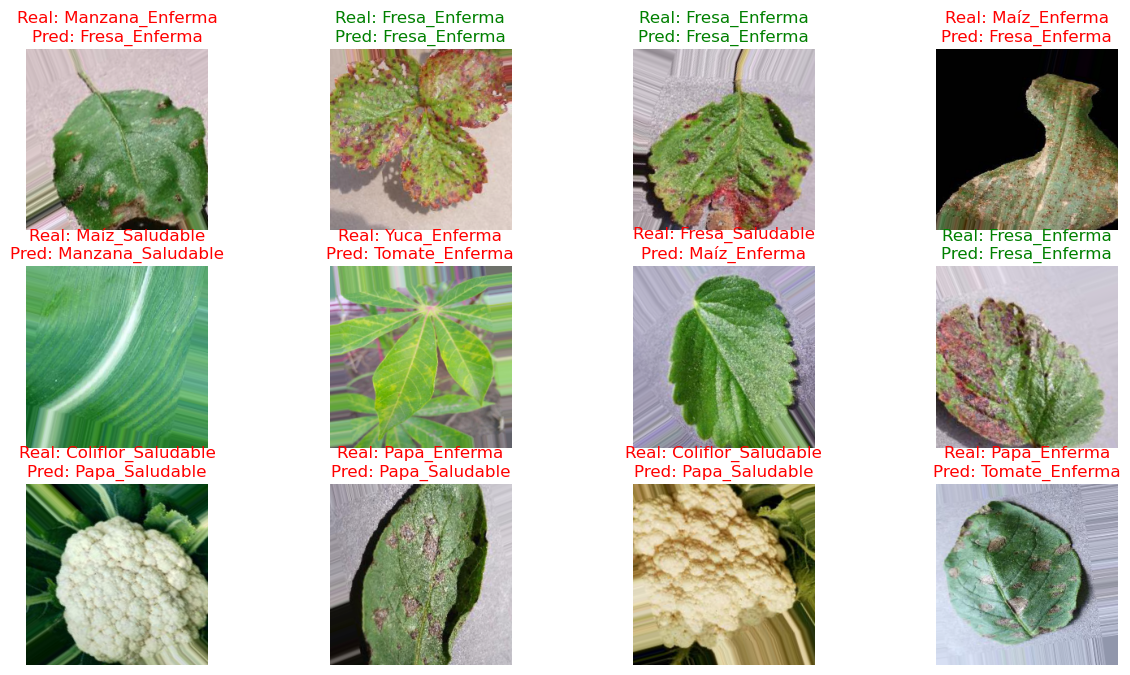

In [19]:
# Función para normalizar imágenes solo para visualización
def normalize_for_display(img):
    img_min = img.min()
    img_max = img.max()
    if img_max > 1.0 or img_min < 0.0:
        img = (img - img_min) / (img_max - img_min + 1e-7)
    return img

# Obtener nombres de clases
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())

# Reiniciar el generador para empezar desde el principio
test_generator.reset()
x_batch, y_true_batch = next(test_generator)

# Obtener predicciones del modelo
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Número de imágenes a mostrar (máximo el tamaño del batch)
num_samples = x_batch.shape[0]

# Mostrar imágenes con etiquetas
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(3, 4, i + 1)
    img_to_show = normalize_for_display(x_batch[i])
    plt.imshow(img_to_show)
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle("Muestreo de Predicciones vs. Etiquetas Reales", fontsize=16, y=1.02)
plt.show()

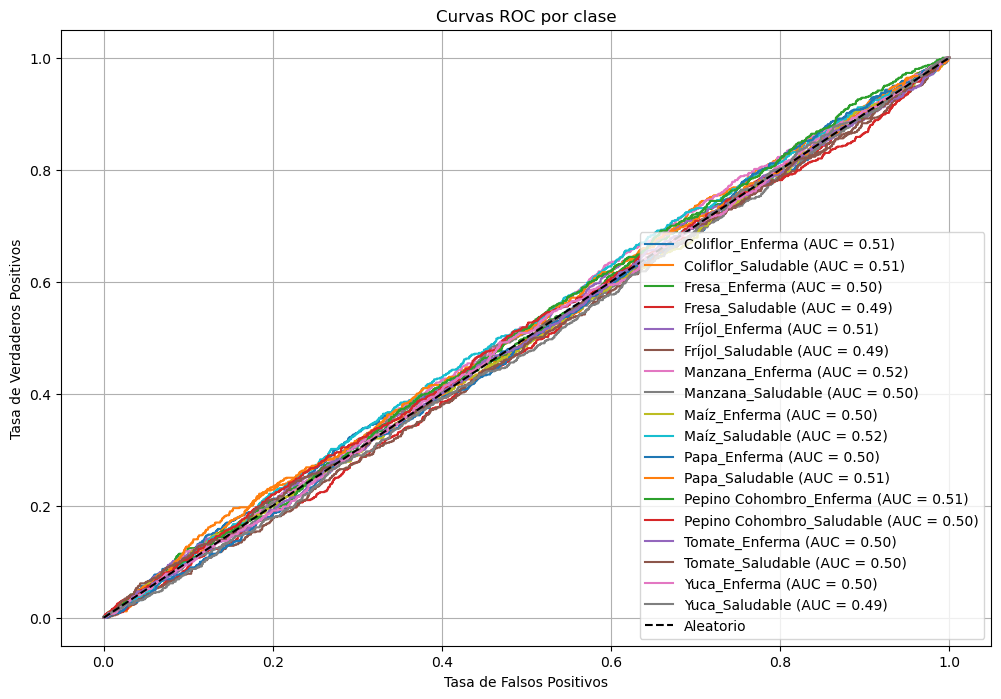

In [20]:
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical


# 3. Convertir etiquetas reales a one-hot
n_classes = y_pred_probs.shape[1]
y_true_onehot = to_categorical(y_true, num_classes=n_classes)

# 4. Calcular ROC y AUC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 5. Obtener nombres de clase
class_names = list(test_generator.class_indices.keys())

# 6. Graficar curvas ROC
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por clase')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [22]:
from sklearn.metrics import roc_auc_score

# AUC macro (promedio de clases, todas igual de importantes)
auc_macro = roc_auc_score(y_true_onehot, y_pred_probs, average='macro')

# AUC micro (promedia sobre todas las instancias)
auc_micro = roc_auc_score(y_true_onehot, y_pred_probs, average='micro')

print(f"AUC Macro promedio: {auc_macro:.4f}")
print(f"AUC Micro promedio: {auc_micro:.4f}")


AUC Macro promedio: 0.5025
AUC Micro promedio: 0.5015


In [23]:
from sklearn.metrics import f1_score
# Asegúrate de tener esto:
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = test_generator.classes

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (micro): {f1_micro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")

# Detalle por clase
class_names = list(test_generator.class_indices.keys())
print("\nReporte de clasificación por clase:")
print(classification_report(y_true, y_pred, target_names=class_names))

Accuracy: 0.0573
F1 Score (macro): 0.0371
F1 Score (micro): 0.0573
F1 Score (weighted): 0.0371

Reporte de clasificación por clase:
                           precision    recall  f1-score   support

         Coliflor_Enferma       0.10      0.00      0.01       700
       Coliflor_Saludable       0.05      0.04      0.05       700
            Fresa_Enferma       0.06      0.26      0.09       700
          Fresa_Saludable       0.07      0.01      0.02       700
           Fríjol_Enferma       0.25      0.00      0.00       700
         Fríjol_Saludable       0.03      0.01      0.02       701
          Manzana_Enferma       0.02      0.00      0.00       700
        Manzana_Saludable       0.06      0.08      0.07       700
             Maíz_Enferma       0.05      0.16      0.08       700
           Maíz_Saludable       0.10      0.00      0.01       700
             Papa_Enferma       0.04      0.03      0.04       700
           Papa_Saludable       0.07      0.19      0.10       

In [26]:
model.save('modelo_17_EfficientNet_Planta_Estadp_Balanceado.h5')

In [28]:
class_indices = train_generator.class_indices  # o test_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}
print(index_to_class)
with open("index_to_class_modelo_17_EfficientNet_Planta_Estadp_Balanceado.json", "w") as f:
    json.dump(index_to_class, f, indent=4, ensure_ascii=False)

{0: 'Maíz_Enferma', 1: 'Tomate_Saludable', 2: 'Yuca_Enferma', 3: 'Pepino Cohombro_Enferma', 4: 'Tomate_Enferma', 5: 'Manzana_Saludable', 6: 'Fresa_Enferma', 7: 'Maíz_Saludable', 8: 'Papa_Enferma', 9: 'Fresa_Saludable', 10: 'Coliflor_Enferma', 11: 'Pepino Cohombro_Saludable', 12: 'Yuca_Saludable', 13: 'Fríjol_Enferma', 14: 'Papa_Saludable', 15: 'Fríjol_Saludable', 16: 'Coliflor_Saludable', 17: 'Manzana_Enferma'}
